Question Two: Stations where time is gain and lost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
links_df = pd.read_csv("../data/stiptheid-gegevens-maandelijksebestanden.csv", sep=";")
links_df.head()

,Month,Link to data
0,2024-02,https://fr.ftp.opendatasoft.com/infrabel/Punct...
1,2024-05,https://fr.ftp.opendatasoft.com/infrabel/Punct...
2,2024-07,https://fr.ftp.opendatasoft.com/infrabel/Punct...
3,2024-08,https://fr.ftp.opendatasoft.com/infrabel/Punct...
4,2024-01,https://fr.ftp.opendatasoft.com/infrabel/Punct...


Combine all the datasets per month for the year 2024 into one dataset.

In [3]:
import requests
from io import StringIO 

all_months = []

for url in links_df["Link to data"]:
    response = requests.get(url)
    if response.status_code == 200:
        month_df = pd.read_csv(StringIO(response.text))
        all_months.append(month_df)
    else:
        print(f"Failed to load: {url}")


df_2024 = pd.concat(all_months, ignore_index=True)

In [4]:
df_2024.head()

,DATDEP,TRAIN_NO,RELATION,TRAIN_SERV,PTCAR_NO,THOP1_COD,LINE_NO_DEP,REAL_TIME_ARR,REAL_TIME_DEP,PLANNED_TIME_ARR,...,DELAY_ARR,DELAY_DEP,CIRC_TYP,RELATION_DIRECTION,PTCAR_LG_NM_NL,LINE_NO_ARR,PLANNED_DATE_ARR,PLANNED_DATE_DEP,REAL_DATE_ARR,REAL_DATE_DEP
0,01FEB2024,2029,IC 07,SNCB/NMBS,376,NaN,12,NaN,6:47:01,NaN,...,NaN,61.0,1,IC 07: ESSEN -> CHARLEROI-CENTRAL,ESSEN,NaN,NaN,01FEB2024,NaN,01FEB2024
1,01FEB2024,2029,IC 07,SNCB/NMBS,1244,D,12,6:51:06,6:51:06,6:50:00,...,66.0,66.0,1,IC 07: ESSEN -> CHARLEROI-CENTRAL,WILDERT,12,01FEB2024,01FEB2024,01FEB2024,01FEB2024
2,01FEB2024,2029,IC 07,SNCB/NMBS,630,=,12,6:53:52,6:55:04,6:54:00,...,-7.0,4.0,1,IC 07: ESSEN -> CHARLEROI-CENTRAL,KALMTHOUT,12,01FEB2024,01FEB2024,01FEB2024,01FEB2024
3,01FEB2024,2029,IC 07,SNCB/NMBS,637,D,12,6:56:26,6:56:26,6:57:00,...,-34.0,-34.0,1,IC 07: ESSEN -> CHARLEROI-CENTRAL,KIJKUIT,12,01FEB2024,01FEB2024,01FEB2024,01FEB2024
4,01FEB2024,2029,IC 07,SNCB/NMBS,539,=,12,6:58:09,6:59:14,6:58:00,...,9.0,14.0,1,IC 07: ESSEN -> CHARLEROI-CENTRAL,HEIDE,12,01FEB2024,01FEB2024,01FEB2024,01FEB2024


In [5]:
df_2024.tail()

,DATDEP,TRAIN_NO,RELATION,TRAIN_SERV,PTCAR_NO,THOP1_COD,LINE_NO_DEP,REAL_TIME_ARR,REAL_TIME_DEP,PLANNED_TIME_ARR,...,DELAY_ARR,DELAY_DEP,CIRC_TYP,RELATION_DIRECTION,PTCAR_LG_NM_NL,LINE_NO_ARR,PLANNED_DATE_ARR,PLANNED_DATE_DEP,REAL_DATE_ARR,REAL_DATE_DEP
23114723,31DEC2024,17306,EXTRA,SNCB/NMBS,1073,NaN,59,21:03:30,21:04:10,20:34:10,...,1760.0,1750.0,1,NaN,SINAAI,59,31DEC2024,31DEC2024,31DEC2024,31DEC2024
23114724,31DEC2024,17306,EXTRA,SNCB/NMBS,749,NaN,59,21:07:05,21:07:05,20:38:00,...,1745.0,1745.0,1,NaN,LOKEREN-OOST,59,31DEC2024,31DEC2024,31DEC2024,31DEC2024
23114725,31DEC2024,17306,EXTRA,SNCB/NMBS,748,NaN,57,21:09:05,21:10:28,20:40:00,...,1745.0,1768.0,1,NaN,LOKEREN,59,31DEC2024,31DEC2024,31DEC2024,31DEC2024
23114726,31DEC2024,17306,EXTRA,SNCB/NMBS,1265,NaN,57,21:16:01,21:17:17,20:47:00,...,1741.0,1757.0,1,NaN,ZELE,57,31DEC2024,31DEC2024,31DEC2024,31DEC2024
23114727,31DEC2024,17306,EXTRA,SNCB/NMBS,319,NaN,NaN,21:24:33,NaN,20:55:00,...,1773.0,NaN,1,NaN,DENDERMONDE,57,31DEC2024,NaN,31DEC2024,NaN


In [6]:
df_2024.isnull().sum()

DATDEP                      0
TRAIN_NO                    0
RELATION                    0
TRAIN_SERV                  0
PTCAR_NO                    0
THOP1_COD             2322285
LINE_NO_DEP           1148052
REAL_TIME_ARR         1149470
REAL_TIME_DEP         1147900
PLANNED_TIME_ARR      1149470
PLANNED_TIME_DEP      1147901
DELAY_ARR             1149392
DELAY_DEP             1147817
CIRC_TYP                    0
RELATION_DIRECTION    1455893
PTCAR_LG_NM_NL              0
LINE_NO_ARR           1149625
PLANNED_DATE_ARR      1149470
PLANNED_DATE_DEP      1147901
REAL_DATE_ARR         1149470
REAL_DATE_DEP         1147900
dtype: int64

In [7]:
df_2024.columns

Index(['DATDEP', 'TRAIN_NO', 'RELATION', 'TRAIN_SERV', 'PTCAR_NO', 'THOP1_COD',
       'LINE_NO_DEP', 'REAL_TIME_ARR', 'REAL_TIME_DEP', 'PLANNED_TIME_ARR',
       'PLANNED_TIME_DEP', 'DELAY_ARR', 'DELAY_DEP', 'CIRC_TYP',
       'RELATION_DIRECTION', 'PTCAR_LG_NM_NL', 'LINE_NO_ARR',
       'PLANNED_DATE_ARR', 'PLANNED_DATE_DEP', 'REAL_DATE_ARR',
       'REAL_DATE_DEP'],
      dtype='str')

Drop missing rows from the needed columns, Delay_Dep and Delay_ARR

In [8]:
df_cleaned = df_2024.dropna(subset=[
    "DELAY_DEP",
    "DELAY_ARR"
])

df_cleaned["DELAY_CHANGE"] = df_cleaned["DELAY_DEP"] - df_cleaned["DELAY_ARR"]


In [9]:
station_delay_change =  (df_cleaned.groupby("PTCAR_LG_NM_NL")["DELAY_CHANGE"]
                         .mean().round(2))

In [10]:
worst_stations = station_delay_change.sort_values(ascending=False).head(5)


best_stations = station_delay_change.sort_values(ascending=True).head(5)


print("Stations where most time is lost:")
print(worst_stations)
print("\nStations where most time is gained:")
print(best_stations)

Stations where most time is lost:
PTCAR_LG_NM_NL
MERELBEKE-CENTRAAL           707.00
TURNHOUT                     464.00
ANTWERPEN-NOORD-BUNDEL A1    444.07
RONET-P.E.                   181.00
MONTZEN                      175.00
Name: DELAY_CHANGE, dtype: float64

Stations where most time is gained:
PTCAR_LG_NM_NL
VORST-RIJTUIGEN-DIENSTPERRON   -70.00
BOOM                           -48.71
OUDENAARDE                     -39.19
EINE                           -31.25
GRAIDE                         -31.17
Name: DELAY_CHANGE, dtype: float64


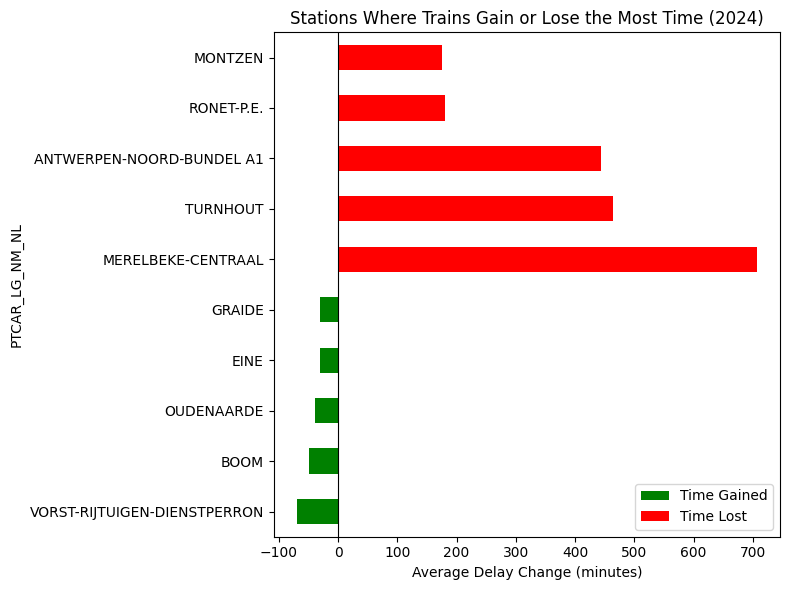

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Combine data and set colors
combined = pd.concat([best_stations, worst_stations])
colors = ["green"] * 5 + ["red"] * 5


combined.plot(kind="barh", color=colors, figsize=(8, 6))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Average Delay Change (minutes)")
plt.title("Stations Where Trains Gain or Lose the Most Time (2024)")

# Add custom legend
legend_elements = [
    Patch(facecolor='green', label='Time Gained'),
    Patch(facecolor='red', label='Time Lost')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()
